# Geneformer model-size sweep on PBMC

1. Read sweep + orig Geneformer curves.
2. Plot train/eval loss — orig Geneformer + each sweep model, x-axis log.
3. Plot MI(protein_counts) vs quality for each sweep model + orig baselines.

In [ ]:
# Gather results by walking the actual on-disk layout:
#   model_sizing_geneformer/model_sizing_geneformer_XX/<size>/<quality>/
#     ├─ config.json                                   (arch + fixed HPs + metadata; written pre-train)
#     ├─ result.json                                   (post-run; status=ok|error, train_time_s)
#     ├─ trainer_state.json                            (final HF log_history: train loss + eval_loss)
#     ├─ checkpoint-*/trainer_state.json               (per-checkpoint snapshots; latest = full history)
#     ├─ checkpoint-*/config.json                      (HF BertConfig -- arch fallback if top-level cfg is missing)
#     └─ MI/<seed>/Y_<signal>_<quality>_geneformer/lmi_mutual_information.txt
import json
import re
from pathlib import Path

import pandas as pd

OUTPUT_DIR = Path('/home/igor/noise_scaling/data/other/model_sizing_geneformer')
MI_SEED = 42
ARCH_KEYS = ('num_embed_dim', 'intermed_size', 'num_attn_heads', 'num_layers', 'max_input_size')
# HF BertConfig keys -> our arch keys
HF_TO_ARCH = {
    'hidden_size':             'num_embed_dim',
    'intermediate_size':       'intermed_size',
    'num_attention_heads':     'num_attn_heads',
    'num_hidden_layers':       'num_layers',
    'max_position_embeddings': 'max_input_size',
}

def _num(s: str):
    try: return int(s)
    except ValueError:
        try: return float(s)
        except ValueError: return s

try:
    import pickle
    TOKEN_DICT_PATH = Path('/home/igor/noise_scaling/data/PBMC/utils/token_dict.pkl')
    with open(TOKEN_DICT_PATH, 'rb') as fp:
        _token_dict = pickle.load(fp)
    VOCAB_SIZE = len(_token_dict)
    PAD_TOKEN_ID = _token_dict.get('<pad>', 0)
except Exception as e:
    print(f'WARNING: could not load token_dict.pkl ({e}); using VOCAB_SIZE=20000')
    VOCAB_SIZE, PAD_TOKEN_ID = 20000, 0

_PARAM_COUNTS: dict = {}
def _trainable_params(arch: dict) -> int:
    key = tuple(int(arch.get(k, 0) or 0) for k in ARCH_KEYS)
    if key in _PARAM_COUNTS:
        return _PARAM_COUNTS[key]
    from transformers import BertConfig, BertForMaskedLM
    hidden, intermed, heads, layers, max_pos = key
    if hidden <= 0 or layers <= 0:
        _PARAM_COUNTS[key] = 0
        return 0
    cfg = BertConfig(
        hidden_size=hidden, num_hidden_layers=layers, num_attention_heads=heads,
        intermediate_size=intermed, max_position_embeddings=max_pos,
        vocab_size=VOCAB_SIZE, pad_token_id=PAD_TOKEN_ID, hidden_act='relu',
        attention_probs_dropout_prob=0.02, hidden_dropout_prob=0.02,
        layer_norm_eps=1e-12, initializer_range=0.02,
    )
    m = BertForMaskedLM(cfg)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    del m
    _PARAM_COUNTS[key] = int(n)
    return int(n)

def _read_hf_log_history(log_history: list[dict]):
    if not log_history:
        return None, None
    tr = [{'step': e['step'], 'train_loss': e['loss']}
          for e in log_history if 'loss' in e and 'step' in e and 'eval_loss' not in e]
    va = [{'step': e['step'], 'val_loss': e['eval_loss']}
          for e in log_history if 'eval_loss' in e and 'step' in e]
    tr_df = pd.DataFrame(tr).sort_values('step').reset_index(drop=True) if tr else None
    va_df = pd.DataFrame(va).sort_values('step').reset_index(drop=True) if va else None
    return tr_df, va_df

def _read_trainer_state(leaf: Path):
    candidates: list[Path] = []
    final = leaf / 'trainer_state.json'
    if final.exists():
        candidates.append(final)
    ckpt_dirs = sorted(
        (p for p in leaf.glob('checkpoint-*') if p.is_dir()),
        key=lambda p: int(p.name.split('-', 1)[1]) if p.name.split('-', 1)[1].isdigit() else -1,
    )
    if ckpt_dirs:
        candidates.append(ckpt_dirs[-1] / 'trainer_state.json')
    for path in candidates:
        if not path.exists() or path.stat().st_size == 0:
            continue
        try:
            state = json.loads(path.read_text())
        except Exception:
            continue
        tr, va = _read_hf_log_history(state.get('log_history', []))
        if (tr is not None and len(tr)) or (va is not None and len(va)):
            return tr, va
    return None, None

def _arch_from_hf_checkpoint(leaf: Path) -> dict:
    """Fallback arch source: latest HF checkpoint config.json in `leaf`.
    Useful when the top-level config.json is missing (e.g. trial still starting
    or config not yet flushed)."""
    ckpt_dirs = sorted(
        (p for p in leaf.glob('checkpoint-*') if p.is_dir()),
        key=lambda p: int(p.name.split('-', 1)[1]) if p.name.split('-', 1)[1].isdigit() else -1,
    )
    for ckpt in reversed(ckpt_dirs):
        cfg_path = ckpt / 'config.json'
        if not cfg_path.exists() or cfg_path.stat().st_size == 0:
            continue
        try:
            hf_cfg = json.loads(cfg_path.read_text())
        except Exception:
            continue
        arch = {ours: hf_cfg[hf] for hf, ours in HF_TO_ARCH.items() if hf in hf_cfg}
        if arch:
            return arch
    return {}

rows = []
CURVES: dict = {}

for trial_dir in sorted(OUTPUT_DIR.glob('model_sizing_geneformer_*')):
    if not trial_dir.is_dir():
        continue
    m = re.match(r'model_sizing_geneformer_(\d+)$', trial_dir.name)
    if not m:
        continue
    trial_id = int(m.group(1))

    for size_dir in sorted(p for p in trial_dir.iterdir() if p.is_dir()):
        size_val = _num(size_dir.name)
        if not isinstance(size_val, (int, float)):
            continue
        for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
            quality_val = _num(q_dir.name)
            if not isinstance(quality_val, (int, float)):
                continue

            cfg_path = q_dir / 'config.json'
            cfg = json.loads(cfg_path.read_text()) if cfg_path.exists() else {}
            arch = dict(cfg.get('arch') or {})
            if not arch or any(k not in arch for k in ARCH_KEYS):
                # Fallback: pull arch from the latest HF checkpoint's config.json
                fallback = _arch_from_hf_checkpoint(q_dir)
                for k, v in fallback.items():
                    arch.setdefault(k, v)
            row = {
                'trial_id': trial_id,
                'trial_name': cfg.get('trial_name', f'model_sizing_geneformer_{trial_id:02d}'),
                'size': int(size_val),
                'quality': float(quality_val),
                **{k: arch.get(k) for k in ARCH_KEYS},
                'trainable_params': _trainable_params(arch) if arch else 0,
            }

            res_path = q_dir / 'result.json'
            if res_path.exists():
                try:
                    res = json.loads(res_path.read_text())
                    row['status'] = res.get('status', 'unknown')
                    row['train_time_s'] = res.get('train_time_s')
                except json.JSONDecodeError:
                    row['status'] = 'corrupt'
            else:
                row['status'] = 'pending'

            train_df, val_df = _read_trainer_state(q_dir)
            if train_df is not None and len(train_df):
                row['train_loss_final'] = float(train_df['train_loss'].iloc[-1])
                row['n_train_steps'] = int(train_df['step'].iloc[-1])
            if val_df is not None and len(val_df):
                row['val_loss_final'] = float(val_df['val_loss'].iloc[-1])
            CURVES[(trial_id, int(size_val), float(quality_val))] = {
                'train': train_df, 'val': val_df,
            }

            mi_root = q_dir / 'MI' / str(MI_SEED)
            if mi_root.is_dir():
                for sig_dir in filter(Path.is_dir, mi_root.iterdir()):
                    sm = re.match(r'Y_(.+?)_[0-9][0-9_.]*(?:_geneformer)?$', sig_dir.name)
                    signal = sm.group(1) if sm else sig_dir.name
                    f = sig_dir / 'lmi_mutual_information.txt'
                    if f.exists():
                        try: row[f'mi_{signal}'] = float(f.read_text().strip())
                        except ValueError: pass
            rows.append(row)

df = pd.DataFrame(rows)
# Arch is constant within a trial_id, so replace every row's arch with the
# MODAL arch of its trial. Two quality dirs in this sweep carry a HF checkpoint
# config.json restored from a different run (trial_00 @ q=0.225772 and
# trial_04 @ q=0.0115083), so ffill/bfill alone wouldn't catch it — those rows
# have non-NaN but WRONG arch values, which misattributes them to a sibling
# trial's param bucket. Mode-within-trial recovers the correct arch;
# MI values on disk remain untouched.
if len(df):
    for k in ARCH_KEYS:
        if k in df.columns:
            df[k] = df.groupby('trial_id')[k].transform(
                lambda s: s.mode().iloc[0] if s.notna().any() else s
            )
    # Recompute trainable_params after arch correction.
    def _row_params(r):
        arch = {k: r[k] for k in ARCH_KEYS if k in r.index and pd.notna(r[k])}
        return _trainable_params(arch) if len(arch) == len(ARCH_KEYS) else 0
    df['trainable_params'] = df.apply(_row_params, axis=1)
    df = df.sort_values(['trial_id', 'size', 'quality']).reset_index(drop=True)
mi_cols_found = sorted(c for c in df.columns if c.startswith('mi_'))
n_trials = df['trial_id'].nunique() if len(df) else 0
n_ok = int((df['status'] == 'ok').sum()) if 'status' in df.columns else 0
n_curves = sum(1 for v in CURVES.values() if v['train'] is not None and len(v['train']))
print(f'{len(df)} rows across {n_trials} trials  ok={n_ok}  curves={n_curves}  mi_cols={mi_cols_found}')
df

Production-replica trial detected: trial_id=3
orig Geneformer curves loaded: train=10/10 val=10/10


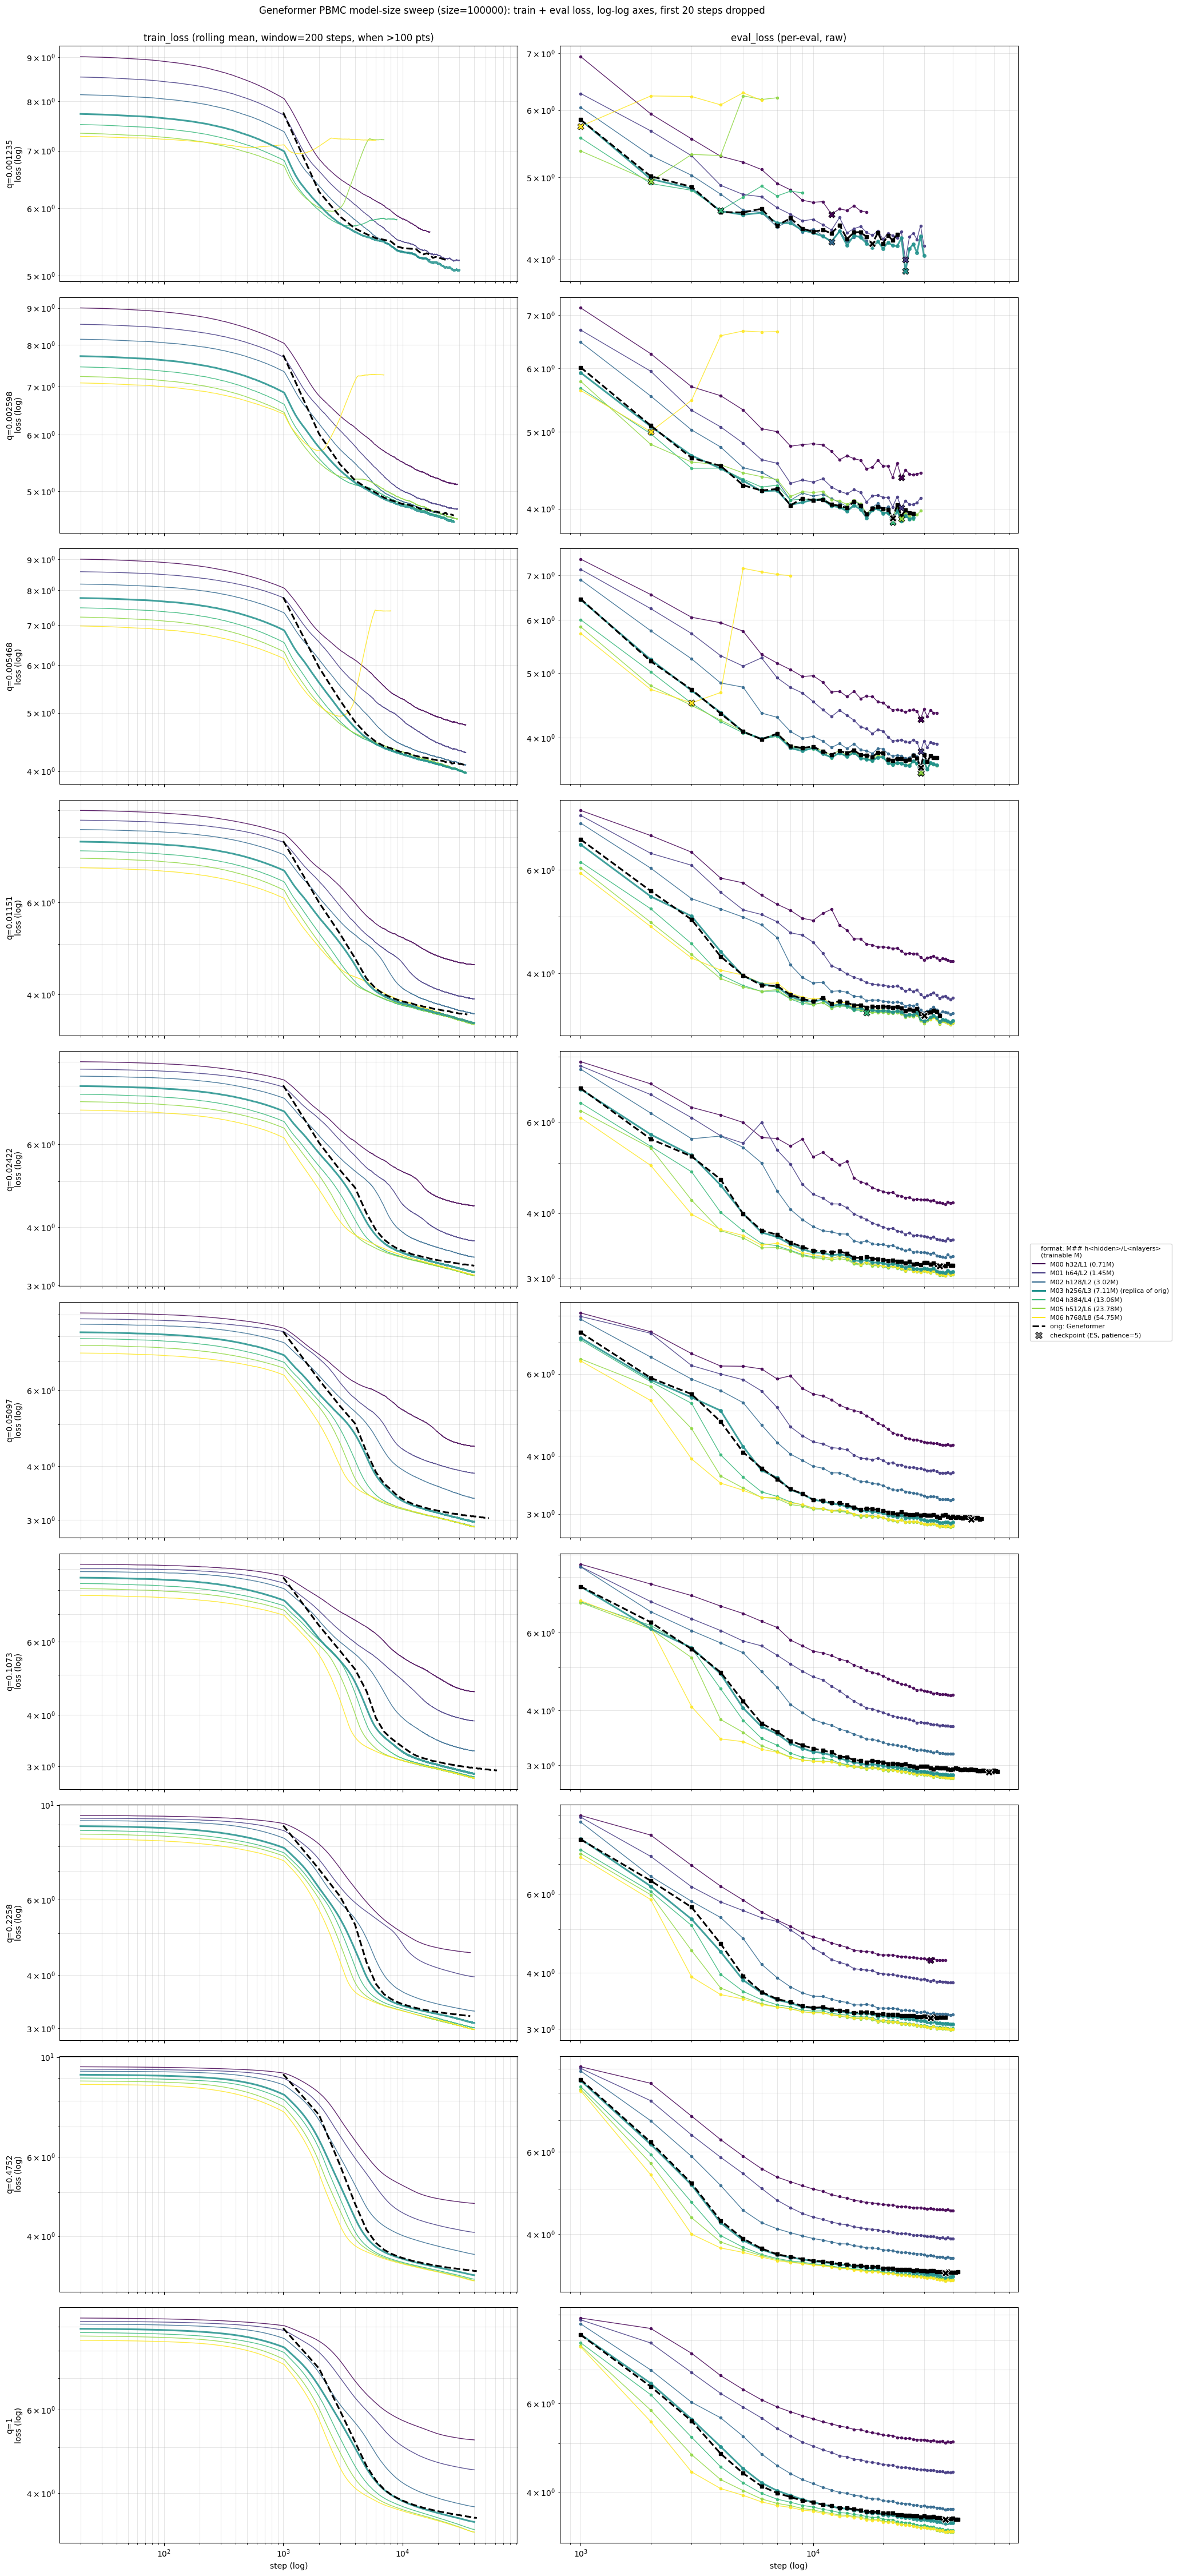

In [2]:
# Train / eval loss curves on LOG-LOG axes: 2 columns (train, eval), 1 row per quality.
# One line per sweep trial + orig-work Geneformer (black dashed) at each quality.
# Train curves smoothed (centered rolling mean) when they have enough points.
# X marker = early-stopping checkpoint (best eval_loss followed by >= ES_PATIENCE worse evals).
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from pathlib import Path

ORIG_GENEFORMER_ROOT = Path('/home/igor/noise_scaling/data/PBMC')
SKIP_STEPS = 20
TRAIN_SMOOTH_WINDOW = 200
SMOOTH_MIN_POINTS = 100
ES_PATIENCE = 5

PARAM_LEGEND_TITLE = (
    'format: M## h<hidden>/L<nlayers>\n'
    '(trainable M)'
)

PRODUCTION_ARCH = {
    'num_embed_dim':  256,
    'intermed_size':  512,
    'num_attn_heads': 4,
    'num_layers':     3,
}
PROD_LINEWIDTH = 2.2

def _find_prod_trial(frame: pd.DataFrame) -> int | None:
    if frame.empty or not set(PRODUCTION_ARCH).issubset(frame.columns):
        return None
    mask = np.ones(len(frame), dtype=bool)
    for k, v in PRODUCTION_ARCH.items():
        col = pd.to_numeric(frame[k], errors='coerce').fillna(-1).astype(int).values
        mask &= (col == int(v))
    hits = frame.loc[mask, 'trial_id'].unique()
    return int(hits[0]) if len(hits) else None

def _orig_geneformer_curves(size: int, quality) -> tuple[pd.DataFrame | None, pd.DataFrame | None]:
    base = ORIG_GENEFORMER_ROOT / str(size) / str(quality) / 'results' / 'Geneformer'
    if not base.is_dir():
        return None, None
    return _read_trainer_state(base)

def _smooth_train(tr: pd.DataFrame | None) -> pd.DataFrame | None:
    if tr is None or not len(tr):
        return tr
    tr = tr[tr['step'] >= SKIP_STEPS].copy()
    if not len(tr):
        return tr
    if len(tr) < SMOOTH_MIN_POINTS:
        return tr
    tr['train_loss'] = tr['train_loss'].rolling(
        window=TRAIN_SMOOTH_WINDOW, min_periods=10, center=True).mean()
    return tr.dropna(subset=['train_loss'])

def _detect_es(va: pd.DataFrame, patience: int = ES_PATIENCE) -> tuple[bool, int, float]:
    if va is None or va.empty:
        return False, 0, float('nan')
    bidx = va['val_loss'].idxmin()
    n_after = len(va) - 1 - va.index.get_loc(bidx)
    return (n_after >= patience, int(va.loc[bidx, 'step']), float(va.loc[bidx, 'val_loss']))

qualities = sorted(df['quality'].unique())
trial_ids = sorted(df['trial_id'].unique())
cmap = plt.get_cmap('viridis')
trial_color = {tid: cmap(i / max(1, len(trial_ids) - 1)) for i, tid in enumerate(trial_ids)}

prod_tid = _find_prod_trial(df)
if prod_tid is None:
    print('WARNING: no sweep trial matches PRODUCTION_ARCH.')
else:
    print(f'Production-replica trial detected: trial_id={prod_tid}')

def _ifmt(x) -> str:
    """Format a numeric value as int, or '?' if NaN/None/non-numeric."""
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return '?'
        return str(int(x))
    except (TypeError, ValueError):
        return '?'

def _trial_label(tid: int) -> str:
    sub = df[df['trial_id'] == tid]
    if sub.empty:
        return f'M{tid:02d}'
    # Prefer a row with valid arch so labels remain informative even when one
    # sibling row (different quality) has a missing config.
    arch_cols = [c for c in ('num_embed_dim', 'num_layers') if c in sub.columns]
    valid = sub.dropna(subset=arch_cols) if arch_cols else sub
    cfg = (valid if len(valid) else sub).iloc[0]
    tag = ' (replica of orig)' if tid == prod_tid else ''
    tp = cfg.get('trainable_params', 0) if hasattr(cfg, 'get') else cfg['trainable_params']
    params_str = f"{tp/1e6:.2f}M" if pd.notna(tp) and tp else '?M'
    return (f"M{int(tid):02d} "
            f"h{_ifmt(cfg.get('num_embed_dim'))}/L{_ifmt(cfg.get('num_layers'))} "
            f"({params_str}){tag}")

trial_label = {tid: _trial_label(tid) for tid in trial_ids}

sizes = sorted({k[1] for k in CURVES}) or [100000]
orig_size = sizes[0]

ORIG_CURVES = {q: _orig_geneformer_curves(orig_size, q) for q in qualities}
n_orig_tr = sum(1 for tr, _ in ORIG_CURVES.values() if tr is not None and len(tr))
n_orig_va = sum(1 for _, va in ORIG_CURVES.values() if va is not None and len(va))
print(f'orig Geneformer curves loaded: train={n_orig_tr}/{len(qualities)} val={n_orig_va}/{len(qualities)}')

n_rows = len(qualities)
fig, axes = plt.subplots(n_rows, 2, figsize=(18, 4.5 * n_rows),
                         sharex='col', squeeze=False)

orig_drawn = False
es_marker_drawn = False
for r, q in enumerate(qualities):
    ax_tr, ax_va = axes[r, 0], axes[r, 1]
    for tid in trial_ids:
        is_prod = (tid == prod_tid)
        lw = PROD_LINEWIDTH if is_prod else 1.0
        keys = [k for k in CURVES if k[0] == tid and np.isclose(k[2], q)]
        for key in keys:
            curves = CURVES[key]
            tr = _smooth_train(curves['train'])
            va_full = curves['val']
            va = va_full[va_full['step'] >= SKIP_STEPS] if va_full is not None and len(va_full) else va_full
            color = trial_color[tid]
            if tr is not None and len(tr):
                ax_tr.plot(tr['step'].values, tr['train_loss'].values,
                           color=color, linewidth=lw, alpha=0.85,
                           zorder=4 if is_prod else 2)
            if va is not None and len(va):
                ax_va.plot(va['step'].values, va['val_loss'].values,
                           color=color, linewidth=lw, alpha=0.85,
                           marker='o', markersize=4 if is_prod else 3,
                           zorder=4 if is_prod else 2)
                es, best_step, best_val = _detect_es(va_full)
                if es:
                    ax_va.scatter([best_step], [best_val],
                                  color=color, marker='X', s=65,
                                  edgecolor='k', linewidth=0.6, zorder=6)
                    es_marker_drawn = True

    otr, ova_full = ORIG_CURVES.get(q, (None, None))
    otr = _smooth_train(otr)
    ova = ova_full[ova_full['step'] >= SKIP_STEPS] if ova_full is not None and len(ova_full) else ova_full
    if otr is not None and len(otr):
        ax_tr.plot(otr['step'].values, otr['train_loss'].values,
                   color='k', linewidth=2.2, linestyle='--', zorder=5)
        orig_drawn = True
    if ova is not None and len(ova):
        ax_va.plot(ova['step'].values, ova['val_loss'].values,
                   color='k', linewidth=2.2, linestyle='--',
                   marker='s', markersize=4, zorder=5)
        orig_drawn = True
        es, best_step, best_val = _detect_es(ova_full)
        if es:
            ax_va.scatter([best_step], [best_val],
                          color='k', marker='X', s=90,
                          edgecolor='w', linewidth=0.8, zorder=7)
            es_marker_drawn = True

    ax_tr.set_xscale('log')
    ax_va.set_xscale('log')
    ax_tr.set_yscale('log')
    ax_va.set_yscale('log')
    ax_tr.set_ylabel(f'q={q:.4g}\nloss (log)')
    ax_tr.grid(alpha=0.3, which='both')
    ax_va.grid(alpha=0.3, which='both')

axes[0, 0].set_title(f'train_loss (rolling mean, window={TRAIN_SMOOTH_WINDOW} steps, when >{SMOOTH_MIN_POINTS} pts)')
axes[0, 1].set_title('eval_loss (per-eval, raw)')
axes[-1, 0].set_xlabel('step (log)')
axes[-1, 1].set_xlabel('step (log)')

legend_handles = [
    Line2D([0], [0], color=trial_color[tid],
           linewidth=PROD_LINEWIDTH if tid == prod_tid else 1.5,
           label=trial_label[tid])
    for tid in trial_ids
]
if orig_drawn:
    legend_handles.append(
        Line2D([0], [0], color='k', linewidth=2.2, linestyle='--',
               label='orig: Geneformer')
    )
if es_marker_drawn:
    legend_handles.append(
        Line2D([0], [0], color='gray', marker='X', linestyle='',
               markersize=9, markeredgecolor='k', markeredgewidth=0.6,
               label=f'checkpoint (ES, patience={ES_PATIENCE})')
    )
legend = fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
                    fontsize=8, title=PARAM_LEGEND_TITLE, title_fontsize=8)
legend.get_title().set_multialignment('left')
fig.suptitle(
    f'Geneformer PBMC model-size sweep (size={orig_size}): train + eval loss, log-log axes, '
    f'first {SKIP_STEPS} steps dropped',
    y=1.0,
)
plt.tight_layout()
plt.show()

In [3]:
# Original-work baselines: load MI for the per-algorithm runs under data/PBMC/<size>/<quality>/results/<algo>/.
import re
from pathlib import Path

import pandas as pd

ORIG_ROOT = Path('/home/igor/noise_scaling/data/PBMC')
ORIG_SIZE = 100000
ORIG_SEED = 42
ORIG_SIGNAL = 'protein_counts'

SIG_RE = re.compile(r'Y_(.+?)_[0-9][0-9_.]*(?:_[A-Za-z]+)?$')

orig_rows = []
size_dir = ORIG_ROOT / str(ORIG_SIZE)
for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
    try:
        quality = float(q_dir.name)
    except ValueError:
        continue
    results_dir = q_dir / 'results'
    if not results_dir.is_dir():
        continue
    for algo_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        algo = algo_dir.name
        if algo in ('TunableState', 'TunableGeneformer'):
            continue
        mi_root = algo_dir / 'model' / 'MI' / str(ORIG_SEED)
        if not mi_root.is_dir():
            continue
        for sig_dir in mi_root.iterdir():
            if not sig_dir.is_dir():
                continue
            m = SIG_RE.match(sig_dir.name)
            signal = m.group(1) if m else sig_dir.name
            if signal != ORIG_SIGNAL:
                continue
            f = sig_dir / 'lmi_mutual_information.txt'
            if not f.exists():
                continue
            try:
                mi_val = float(f.read_text().strip())
            except ValueError:
                continue
            orig_rows.append({'algo': algo, 'quality': quality, 'mi': mi_val})

orig_df = pd.DataFrame(orig_rows).sort_values(['algo', 'quality']).reset_index(drop=True)
print(f'{len(orig_df)} original-work points across {orig_df["algo"].nunique()} algos: {sorted(orig_df["algo"].unique())}')
orig_df

50 original-work points across 5 algos: ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']


,algo,quality,mi
0,Geneformer,0.001235,0.74752
1,Geneformer,0.002598,1.30775
2,Geneformer,0.005468,1.70259
3,Geneformer,0.011508,2.29315
4,Geneformer,0.024220,2.77658
5,Geneformer,0.050973,3.09976
6,Geneformer,0.107277,3.45581
7,Geneformer,0.225772,3.50053
8,Geneformer,0.475155,3.66358
9,Geneformer,1.000000,3.43401


In [ ]:
# MI overlay, two panels (shared y):
#   Left:  sweep MI curves + orig Geneformer baseline.
#   Right: all original-work baselines.
import matplotlib.pyplot as plt
from pathlib import Path

mi_col = 'mi_protein_counts'
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)

algo_colors = {
    'State':            'k',
    'Geneformer':       'tab:red',
    'SCVI':             'tab:green',
    'PCA':              'tab:purple',
    'RandomProjection': 'tab:gray',
}

trial_ids = sorted(df['trial_id'].unique())
cmap = plt.get_cmap('viridis')
trial_color = {tid: cmap(i / max(1, len(trial_ids) - 1)) for i, tid in enumerate(trial_ids)}

if mi_col not in df.columns:
    print(f"WARNING: '{mi_col}' column not yet populated (no MI files on disk).")

for tid in trial_ids:
    if mi_col not in df.columns:
        break
    sub = df[(df['trial_id'] == tid) & df[mi_col].notna()].sort_values('quality')
    if sub.empty:
        continue
    # Prefer a row with valid arch for labels even when some sibling rows
    # have NaN arch (e.g. their config.json wasn't on disk at load time).
    valid = sub.dropna(subset=[c for c in ('num_embed_dim', 'num_layers') if c in sub.columns])
    cfg = (valid if len(valid) else sub).iloc[0]
    tp = cfg.get('trainable_params', 0)
    params_str = f"{tp/1e6:.2f}M" if pd.notna(tp) and tp else '?M'
    label = (f"M{int(tid):02d} "
             f"h{_ifmt(cfg.get('num_embed_dim'))}/L{_ifmt(cfg.get('num_layers'))} "
             f"({params_str})")
    ax_l.plot(sub['quality'].values, sub[mi_col].values,
              marker='o', linewidth=1.0, alpha=0.85,
              color=trial_color[tid], label=label)

gf_sub = orig_df[orig_df['algo'] == 'Geneformer'].sort_values('quality')
if not gf_sub.empty:
    ax_l.plot(gf_sub['quality'].values, gf_sub['mi'].values,
              marker='s', linewidth=2.5, linestyle='--',
              color=algo_colors['Geneformer'], label='orig: Geneformer', zorder=5)

ax_l.set_xscale('log')
ax_l.set_xlabel('quality (downsampling factor)')
ax_l.set_ylabel(f'MI({ORIG_SIGNAL})  [nats]')
ax_l.set_title('Model-size sweep (thin) vs orig Geneformer (dashed)')
ax_l.grid(alpha=0.3)
ax_l.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, ncol=1)

for algo, sub in orig_df.groupby('algo'):
    sub = sub.sort_values('quality')
    ax_r.plot(sub['quality'].values, sub['mi'].values,
              marker='s', linewidth=2.5, linestyle='--',
              color=algo_colors.get(algo, None),
              label=f'orig: {algo}', zorder=5)

ax_r.set_xscale('log')
ax_r.set_xlabel('quality (downsampling factor)')
ax_r.set_title('Original-work baselines (all algos)')
ax_r.grid(alpha=0.3)
ax_r.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=1)

fig.suptitle(f'PBMC size={ORIG_SIZE}: Geneformer model-size sweep vs original-work baselines')
plt.tight_layout()

# Save the model-size sweep (left panel) to CSV, now INCLUDING the per-trial
# architecture columns so the CSV is self-describing:
#   dataset, size, quality,
#   num_embed_dim, intermed_size, num_attn_heads, num_layers, max_input_size,
#   trainable_params_M, mi_protein_counts
# After the mode-per-trial arch fix upstream, every row has consistent arch
# values within a trial, so the (dataset, size, quality, trainable_params_M)
# key is unique — no duplicate rows.
FINAL_RESULTS_DIR = Path('/home/igor/noise_scaling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results')
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_NAME = 'PBMC'
if mi_col in df.columns:
    arch_cols = [c for c in ARCH_KEYS if c in df.columns]
    sweep_cols = ['size', 'quality', *arch_cols, 'trainable_params', mi_col]
    sweep_cols = [c for c in sweep_cols if c in df.columns]
    sweep_out = (df.loc[df[mi_col].notna(), sweep_cols]
                 .sort_values(['trainable_params', 'size', 'quality'])
                 .reset_index(drop=True))
    sweep_out['trainable_params_M'] = sweep_out['trainable_params'] / 1e6
    sweep_out = sweep_out.drop(columns=['trainable_params'])
    sweep_out.insert(0, 'dataset', DATASET_NAME)
    sweep_out = sweep_out[['dataset', 'size', 'quality', *arch_cols,
                           'trainable_params_M', mi_col]]
    dup_mask = sweep_out.duplicated(subset=['dataset', 'size', 'quality',
                                            'trainable_params_M'], keep=False)
    assert not dup_mask.any(), f'unexpected duplicates after arch fix:\n{sweep_out[dup_mask]}'
    sweep_csv = FINAL_RESULTS_DIR / 'geneformer_model_size_sweep.csv'
    sweep_out.to_csv(sweep_csv, index=False)
    print(f'Saved {len(sweep_out)} sweep rows to {sweep_csv} (cols: {list(sweep_out.columns)})')

plt.show()

In [ ]:
# Save the LEFT panel (Geneformer model-size sweep MI curves — no orig Geneformer
# baseline) as a PNG, reading ONLY from the saved CSV in final_results/ so this cell
# is independent of the in-notebook df / orig_df.
# One line per distinct trainable_params_M (model size); viridis colormap ordered
# by parameter count.
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

FR_DIR = Path('/home/igor/noise_scaling/Scaling-up-measurement-noise-scaling-laws/analysis/final_results')
CSV_PATH = FR_DIR / 'geneformer_model_size_sweep.csv'
OUT_PATH = FR_DIR / 'geneformer_model_size_sweep.png'

csv_df = pd.read_csv(CSV_PATH)
mi_col = 'mi_protein_counts'
size_val = csv_df['size'].iloc[0] if 'size' in csv_df.columns and len(csv_df) else ''

param_groups = sorted(csv_df['trainable_params_M'].unique())
cmap = plt.get_cmap('viridis')
group_color = {p: cmap(i / max(1, len(param_groups) - 1)) for i, p in enumerate(param_groups)}

fig, ax_l = plt.subplots(figsize=(8.0, 4.8))
for i, p in enumerate(param_groups):
    sub = csv_df[csv_df['trainable_params_M'] == p].sort_values('quality')
    if sub.empty:
        continue
    label = f'M{i:02d} ({p:.2f}M)'
    ax_l.plot(sub['quality'].values, sub[mi_col].values,
              marker='o', linewidth=1.0, alpha=0.85,
              color=group_color[p], label=label)

ax_l.set_xscale('log')
ax_l.set_xlabel('quality (downsampling factor)')
ax_l.set_ylabel('MI(protein_counts)  [nats]')
ax_l.set_title(f'PBMC size={size_val}: Geneformer model-size sweep MI curves')
ax_l.grid(alpha=0.3)
ax_l.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, ncol=1,
            title='trainable params')

plt.tight_layout()
fig.savefig(OUT_PATH, dpi=150, bbox_inches='tight')
print(f'Wrote {OUT_PATH}')
plt.show()